# ResNet50 Transfer Learning: Road Damage Classification


## 1. Set Project Path

In [1]:
import os

PROJECT_DIR = r"C:\Users\skjha\Documents\Codex\2026-06-01\2-road-damage-detection-for-smart"
os.chdir(PROJECT_DIR)
print("Current directory:", os.getcwd())

Current directory: C:\Users\skjha\Documents\Codex\2026-06-01\2-road-damage-detection-for-smart


## 2. Import Libraries

In [2]:
from pathlib import Path
import json
import random
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPU devices: []


## 3. Configuration

In [3]:
DATA_DIR = Path("data/processed")
MODEL_DIR = Path("ml/models")
REPORT_DIR = Path("ml/reports")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

INITIAL_LEARNING_RATE = 1e-3
FINE_TUNE_LEARNING_RATE = 1e-5
INITIAL_EPOCHS = 15
FINE_TUNE_EPOCHS = 10
DROPOUT_RATE = 0.40

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 4. Build Metadata Table for EDA and Class Weights

In [4]:
def build_metadata(data_dir):
    rows = []
    for split in ["train", "val", "test"]:
        split_dir = data_dir / split
        for class_dir in sorted(split_dir.iterdir()):
            if not class_dir.is_dir():
                continue
            for image_path in class_dir.glob("*.jpg"):
                image = cv2.imread(str(image_path))
                if image is None:
                    continue
                height, width = image.shape[:2]
                rows.append({
                    "split": split,
                    "class_name": class_dir.name,
                    "path": str(image_path),
                    "width": width,
                    "height": height,
                    "aspect_ratio": width / height,
                })
    return pd.DataFrame(rows)

metadata_df = build_metadata(DATA_DIR)
metadata_df.groupby(["split", "class_name"]).size().unstack(fill_value=0)

class_name,crack,manhole,pothole
split,,,
test,347,69,94
train,1579,301,442
val,341,73,82


## 5. Quick Class Distribution Plot

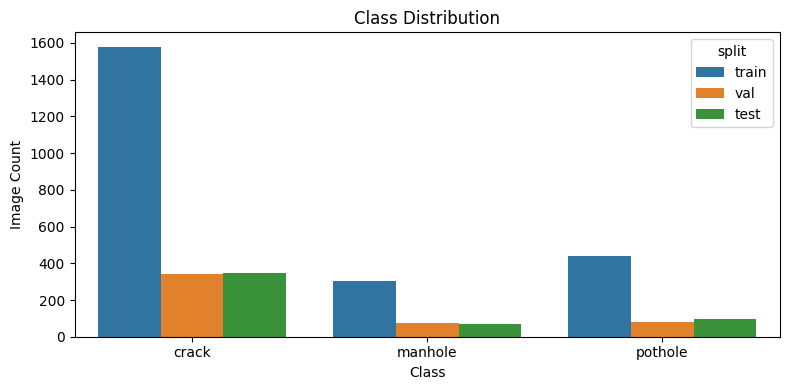

In [5]:
plt.figure(figsize=(8, 4))
sns.countplot(data=metadata_df, x="class_name", hue="split")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

## 6. Load Dataset with Keras

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "train",
    labels="inferred",
    label_mode="categorical",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "val",
    labels="inferred",
    label_mode="categorical",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "test",
    labels="inferred",
    label_mode="categorical",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Class names:", class_names)
print("Number of classes:", NUM_CLASSES)

Found 2322 files belonging to 3 classes.
Found 496 files belonging to 3 classes.
Found 510 files belonging to 3 classes.
Class names: ['crack', 'manhole', 'pothole']
Number of classes: 3


In [7]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

## 7. Compute Class Weights Using sklearn

In [8]:
train_labels = metadata_df[metadata_df["split"] == "train"]["class_name"].to_numpy()

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(class_names),
    y=train_labels,
)

class_weights = {index: float(weight) for index, weight in enumerate(weights)}
class_weights

{0: 0.4901836605446485, 1: 2.5714285714285716, 2: 1.751131221719457}

## 8. Build ResNet50 Transfer Learning Model

In the first stage, the ResNet50 base is frozen. Only the custom classification head trains.

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.04),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomContrast(0.15),
], name="data_augmentation")

inputs = tf.keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3), name="input_image")
x = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)

base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_tensor=x,
)

base_model.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(base_model.output)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.L2(1e-4))(x)
x = tf.keras.layers.Dropout(DROPOUT_RATE)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="damage_class")(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs, name="resnet50_transfer_learning")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 21s 0us/step


Model: "resnet50_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ data_augmentation             │ (None, 224, 224, 3)       │               0 │ input_image[0][0]          │
│ (Sequential)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 224, 224)          │               0 │ data_augmentation[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_1 (GetItem)          │ (None, 224, 224)          │               0 │ data_augmentation[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_2 (GetItem)          │ (None, 224, 224)          │               0 │ data_augmentation[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stack (Stack)                 │ (None, 224, 224, 3)       │               0 │ get_item[0][0],            │
│                               │                           │                 │ get_item_1[0][0],          │
│                               │                           │                 │ get_item_2[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 224, 224, 3)       │               0 │ stack[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 24,121,219 (92.02 MB)

 Trainable params: 529,411 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

## 9. Compile Frozen ResNet50 Model

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LEARNING_RATE),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc", multi_label=True),
    ],
)

## 10. Train Classification Head

In [11]:
initial_checkpoint_path = MODEL_DIR / "road_damage_resnet50_frozen.keras"

initial_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        initial_checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
]

start_time = time.time()

history_frozen = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weights,
    callbacks=initial_callbacks,
)

print(f"Frozen training time: {(time.time() - start_time) / 60:.2f} minutes")

Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5656 - auc: 0.7797 - loss: 1.4429 - precision: 0.5775 - recall: 0.5512
Epoch 1: val_accuracy improved from -inf to 0.69758, saving model to ml\models\road_damage_resnet50_frozen.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.5668 - auc: 0.7802 - loss: 1.4417 - precision: 0.5787 - recall: 0.5523 - val_accuracy: 0.6976 - val_auc: 0.8805 - val_loss: 0.8989 - val_precision: 0.7231 - val_recall: 0.6633 - learning_rate: 0.0010
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7598 - auc: 0.9015 - loss: 0.8832 - precision: 0.7698 - recall: 0.7431
Epoch 2: val_accuracy improved from 0.69758 to 0.80444, saving model to ml\models\road_damage_resnet50_frozen.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.7598 - auc: 0.9015 - loss: 0.8829 - precision: 0.7699 - recall: 0.7431 - val_accuracy: 0.8044 - val_auc: 0.9253 - val_loss: 0.6557 - val_precision: 0.8344 - val_recall: 0.7722 - learning_rate: 0.

## 11. Fine-Tune Top ResNet50 Layers

Now we unfreeze only the top part of ResNet50 and train with a very small learning rate. This lets the model adapt to road damage images without destroying pretrained features.

In [14]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

trainable_count = sum(1 for layer in model.layers if layer.trainable)
print("Trainable model-level layers:", trainable_count)
print("Trainable ResNet layers:", sum(1 for layer in base_model.layers if layer.trainable))

Trainable model-level layers: 45
Trainable ResNet layers: 40


In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LEARNING_RATE),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc", multi_label=True),
    ],
)

## 12. Train Fine-Tuned Model

In [16]:
fine_tune_checkpoint_path = MODEL_DIR / "road_damage_resnet50.keras"

fine_tune_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        fine_tune_checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
]

start_time = time.time()

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=fine_tune_callbacks,
)

print(f"Fine-tuning time: {(time.time() - start_time) / 60:.2f} minutes")

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8380 - auc: 0.9515 - loss: 0.5712 - precision: 0.8650 - recall: 0.8163
Epoch 1: val_accuracy improved from -inf to 0.83669, saving model to ml\models\road_damage_resnet50.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.8380 - auc: 0.9516 - loss: 0.5713 - precision: 0.8649 - recall: 0.8163 - val_accuracy: 0.8367 - val_auc: 0.9275 - val_loss: 0.6616 - val_precision: 0.8526 - val_recall: 0.8165 - learning_rate: 1.0000e-05
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8398 - auc: 0.9644 - loss: 0.5222 - precision: 0.8569 - recall: 0.8131
Epoch 2: val_accuracy did not improve from 0.83669
73/73 ━━━━━━━━━━━━━━━━━━━━ 193s 3s/step - accuracy: 0.8400 - auc: 0.9644 - loss: 0.5223 - precision: 0.8570 - recall: 0.8133 - val_accuracy: 0.8246 - val_auc: 0.9282 - val_loss: 0.6672 - val_precision: 0.8428 - val_recall: 0.8105 - learning_rate: 1.0000e-05
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy

## 13. Combine Training History

In [17]:
history_df = pd.concat(
    [
        pd.DataFrame(history_frozen.history).assign(stage="frozen"),
        pd.DataFrame(history_fine.history).assign(stage="fine_tune"),
    ],
    ignore_index=True,
)

history_df.to_csv(REPORT_DIR / "road_damage_resnet50_history.csv", index=False)
history_df.tail()

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate,stage
16,0.847545,0.964821,0.529945,0.863125,0.825581,0.824597,0.928246,0.667231,0.842767,0.810484,1.000000e-05,fine_tune
17,0.871662,0.972433,0.488715,0.887595,0.853575,0.824597,0.924480,0.674640,0.836820,0.806452,1.000000e-05,fine_tune
18,0.885444,0.978947,0.457145,0.903734,0.865202,0.824597,0.924983,0.668534,0.836134,0.802419,3.000000e-06,fine_tune
19,0.882429,0.978662,0.456519,0.896829,0.864772,0.824597,0.925915,0.665713,0.840671,0.808468,3.000000e-06,fine_tune
20,0.888889,0.980972,0.449616,0.903760,0.869509,0.826613,0.926177,0.664138,0.839248,0.810484,9.000000e-07,fine_tune


## 14. Plot Training Curves

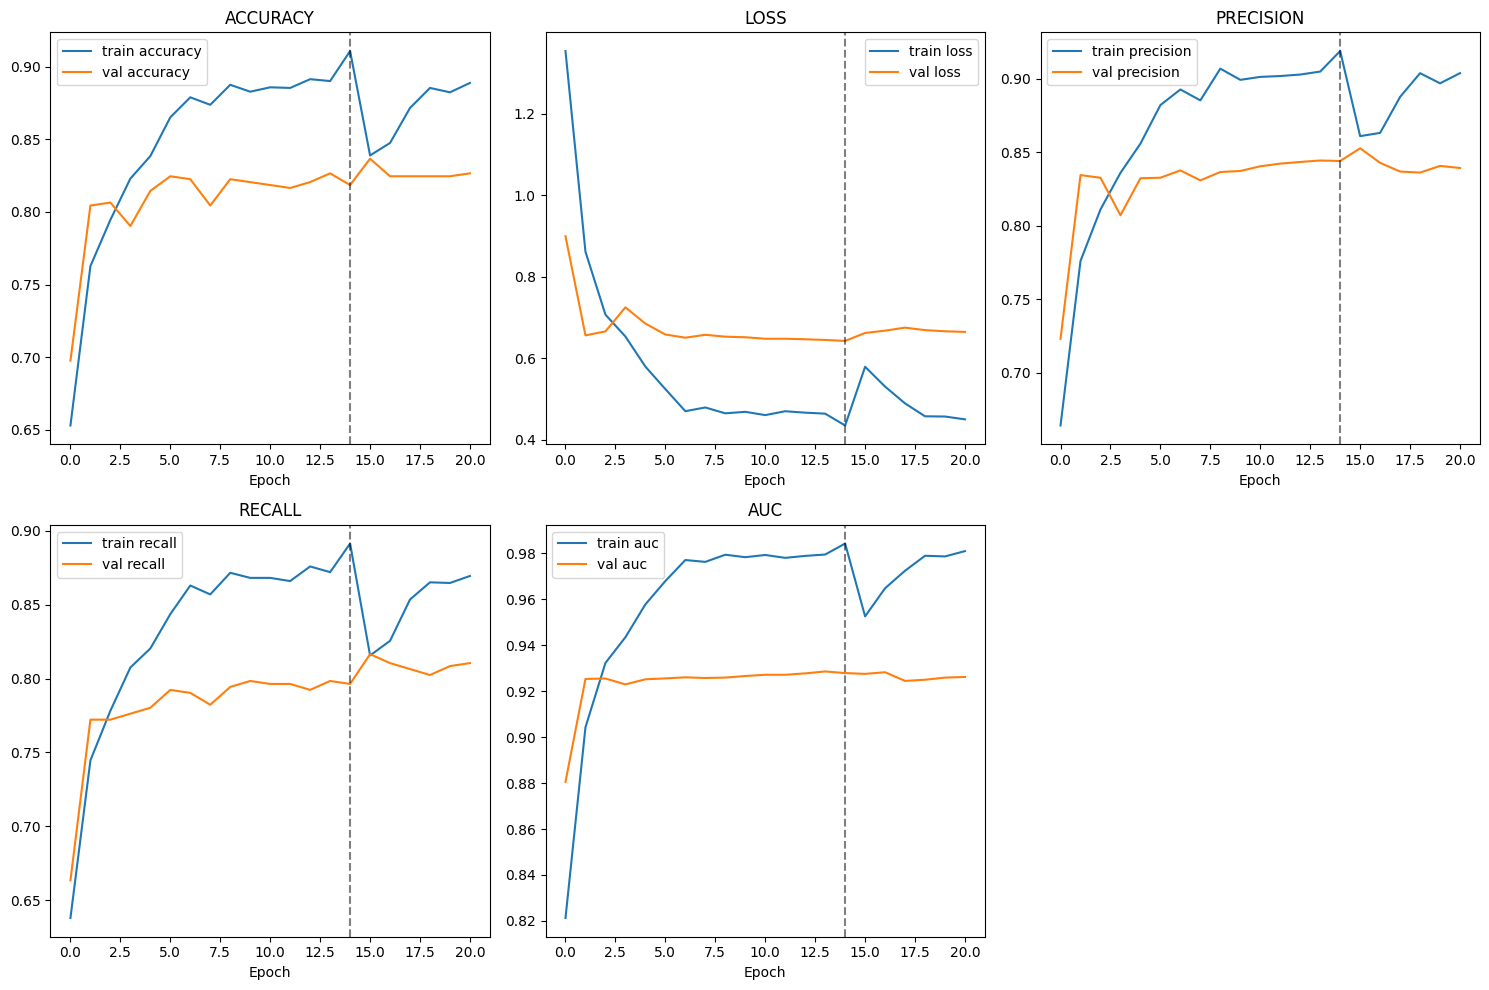

In [18]:
metrics_to_plot = ["accuracy", "loss", "precision", "recall", "auc"]

plt.figure(figsize=(15, 10))
for index, metric in enumerate(metrics_to_plot, start=1):
    plt.subplot(2, 3, index)
    plt.plot(history_df[metric], label=f"train {metric}")
    plt.plot(history_df[f"val_{metric}"], label=f"val {metric}")
    plt.axvline(len(history_frozen.history["loss"]) - 1, color="black", linestyle="--", alpha=0.5)
    plt.title(metric.upper())
    plt.xlabel("Epoch")
    plt.legend()

plt.tight_layout()
plt.show()

## 15. Evaluate ResNet50 with Keras

In [19]:
keras_test_results = model.evaluate(test_ds, verbose=1)
dict(zip(model.metrics_names, keras_test_results))

16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9035 - auc: 0.3384 - loss: 0.5127 - precision: 0.9144 - recall: 0.8945


{'loss': 0.6170361638069153, 'compile_metrics': 0.8490195870399475}

## 16. Evaluate ResNet50 with sklearn

In [20]:
y_true = []
y_prob = []

for image_batch, label_batch in test_ds:
    probabilities = model.predict(image_batch, verbose=0)
    y_prob.append(probabilities)
    y_true.extend(np.argmax(label_batch.numpy(), axis=1))

y_prob = np.vstack(y_prob)
y_true = np.array(y_true)
y_pred = np.argmax(y_prob, axis=1)

resnet_metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
    "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
}

try:
    y_true_binary = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
    resnet_metrics["roc_auc_ovr_macro"] = roc_auc_score(y_true_binary, y_prob, average="macro", multi_class="ovr")
except ValueError as error:
    resnet_metrics["roc_auc_ovr_macro"] = None
    print("AUC skipped:", error)

resnet_metrics

{'accuracy': 0.8490196078431372,
 'precision_macro': 0.7673892289789466,
 'recall_macro': 0.8058947920933967,
 'f1_macro': 0.7834277350591098,
 'precision_weighted': 0.8573652713575289,
 'recall_weighted': 0.8490196078431372,
 'f1_weighted': 0.8516082131472005,
 'roc_auc_ovr_macro': 0.9465826843271463}

In [21]:
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

              precision    recall  f1-score   support

       crack       0.94      0.90      0.92       347
     manhole       0.67      0.84      0.75        69
     pothole       0.69      0.68      0.68        94

    accuracy                           0.85       510
   macro avg       0.77      0.81      0.78       510
weighted avg       0.86      0.85      0.85       510



## 17. Confusion Matrix

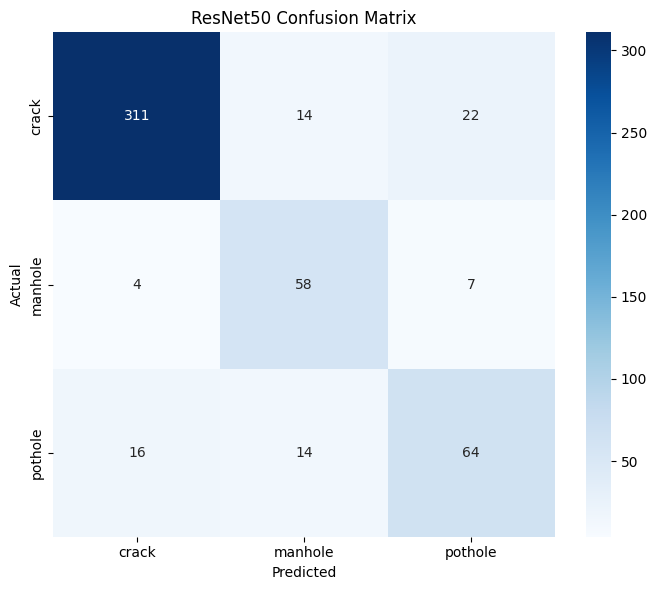

In [22]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 18. Save ResNet50 Model, Labels, and Metrics

In [23]:
model.save(MODEL_DIR / "road_damage_resnet50.keras")
(MODEL_DIR / "road_damage_resnet50_labels.json").write_text(json.dumps(class_names, indent=2), encoding="utf-8")
(REPORT_DIR / "road_damage_resnet50_metrics.json").write_text(json.dumps(resnet_metrics, indent=2), encoding="utf-8")

print("Saved model:", MODEL_DIR / "road_damage_resnet50.keras")
print("Saved labels:", MODEL_DIR / "road_damage_resnet50_labels.json")
print("Saved metrics:", REPORT_DIR / "road_damage_resnet50_metrics.json")

Saved model: ml\models\road_damage_resnet50.keras
Saved labels: ml\models\road_damage_resnet50_labels.json
Saved metrics: ml\reports\road_damage_resnet50_metrics.json


## 19. Compare CNN Baseline vs ResNet50

In [24]:
cnn_metrics_path = REPORT_DIR / "road_damage_self_contained_cnn_metrics.json"

if cnn_metrics_path.exists():
    cnn_metrics = json.loads(cnn_metrics_path.read_text(encoding="utf-8"))
    comparison_df = pd.DataFrame([
        {"model": "Custom CNN", **cnn_metrics},
        {"model": "ResNet50", **resnet_metrics},
    ])
    display(comparison_df)
else:
    print("CNN metrics file not found yet. Finish the CNN notebook first, then rerun this cell.")

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr_macro
0,Custom CNN,0.515686,0.424853,0.450344,0.406285,0.639649,0.515686,0.546523,0.656337
1,ResNet50,0.849020,0.767389,0.805895,0.783428,0.857365,0.849020,0.851608,0.946583
